**EXERCISE CHAPTER 3 NO. 2**

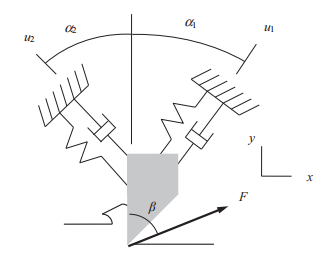

# Exercise Chapter 3 No. 2
## Turning Dynamics — Time Domain Simulation

**Reference:** MD_101-109.pdf — *Example 3.6: Stability Evaluation by Time Domain Simulation*

### System Parameters

| Parameter | Mode 1 (u₁) | Mode 2 (u₂) |
|-----------|-------------|-------------|
| Mass, m | 1 kg | 1 kg |
| Damping, c | 450 N·s/m | 650 N·s/m |
| Stiffness, k | 2×10⁷ N/m | 3×10⁷ N/m |
| Mode angle, α | α₁ = 35° | α₂ = 55° |

**Cutting parameters:**
- Cutting force angle: φ = 65°
- Mean chip thickness: hₘ = 0.1 mm
- Specific force: Kₛ = 2000 N/mm²

---
## a. Calculate μ₁ and μ₂, Plot Real Part, Imaginary Part, and Oriented FRF

**Directional Orientation Factors** (Eq. 3.31):
$$\mu_1 = \cos(\varphi - \alpha_1)\cos\alpha_1$$
$$\mu_2 = \cos(\varphi + \alpha_2)\cos\alpha_2$$

**Oriented FRF:**
$$G_{orient}(f) = \mu_1 G_1(f) + \mu_2 G_2(f)$$

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ─── System Parameters ─────────────────────────────────────
m1 = 1      # kg
c1 = 450    # N·s/m
k1 = 2e7   # N/m
a1 = 35    # deg

m2 = 1      # kg
c2 = 650    # N·s/m
k2 = 3e7   # N/m
a2 = 55    # deg

beta = 65  # deg (cutting force angle φ)

# ─── Directional Orientation Factors (Eq. 3.31) ─────────
u1 = math.cos(math.radians(beta - a1)) * math.cos(math.radians(a1))
u2 = math.cos(math.radians(beta + a2)) * math.cos(math.radians(a2))

# ─── Natural Frequencies and Damping Ratios ────────────────
wn1   = math.sqrt(k1 / m1)                   # rad/s
wn2   = math.sqrt(k2 / m2)                   # rad/s
zeta1 = c1 / (2 * math.sqrt(m1 * k1))
zeta2 = c2 / (2 * math.sqrt(m2 * k2))

fn1 = wn1 / (2 * math.pi)  # Hz
fn2 = wn2 / (2 * math.pi)  # Hz

print(f"Natural frequency mode 1 : fn1 = {fn1:.2f} Hz")
print(f"Natural frequency mode 2 : fn2 = {fn2:.2f} Hz")
print(f"Damping ratio mode 1     : ζ1  = {zeta1:.4f}")
print(f"Damping ratio mode 2     : ζ2  = {zeta2:.4f}")
print(f"\nDirectional Orientation Factors:")
print(f"  μ1 = cos({beta}-{a1})·cos({a1}) = {u1:.4f}")
print(f"  μ2 = cos({beta}+{a2})·cos({a2}) = {u2:.4f}")

Natural frequency mode 1 : fn1 = 711.76 Hz
Natural frequency mode 2 : fn2 = 871.73 Hz
Damping ratio mode 1     : ζ1  = 0.0503
Damping ratio mode 2     : ζ2  = 0.0593

Directional Orientation Factors:
  μ1 = cos(65-35)·cos(35) = 0.7094
  μ2 = cos(65+55)·cos(55) = -0.2868


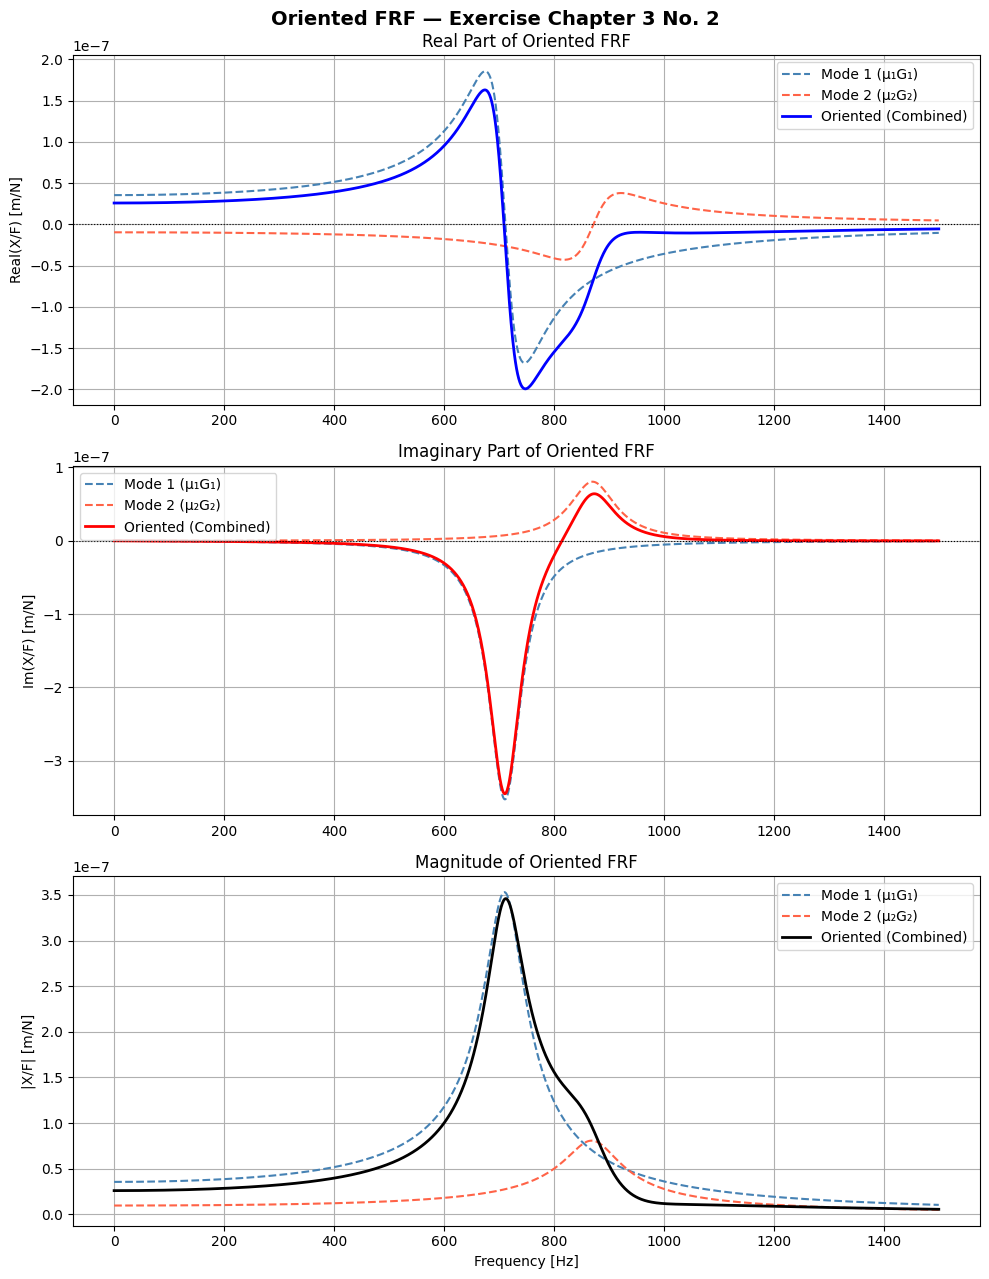

In [11]:
# ─── Frequency Range (0–1500 Hz) ──────────────────────────
f_range = np.linspace(0, 1500, 1501)
omega   = 2 * np.pi * f_range   # rad/s

# ─── FRF Function (Receptance) ──────────────────────────────
def calculate_frf(w, mu, wn, zeta, k):
    """Calculate FRF: G(f) = (μ/k) / (1 - r² + 2jζr), r = ω/ωn"""
    r = w / wn
    return (mu / k) / (1 - r**2 + 2j * zeta * r)

# ─── Calculate Individual and Combined FRF ───────────────────
frf1     = calculate_frf(omega, u1, wn1, zeta1, k1)
frf2     = calculate_frf(omega, u2, wn2, zeta2, k2)
frf_combined = frf1 + frf2   # Oriented FRF

# ─── Plotting ─────────────────────────────────────────────
fig, axs = plt.subplots(3, 1, figsize=(10, 13))
fig.suptitle('Oriented FRF — Exercise Chapter 3 No. 2', fontsize=14, fontweight='bold')

# Real Part
axs[0].plot(f_range, frf1.real,        '--', color='steelblue',  label='Mode 1 (μ₁G₁)')
axs[0].plot(f_range, frf2.real,        '--', color='tomato',     label='Mode 2 (μ₂G₂)')
axs[0].plot(f_range, frf_combined.real, 'b', linewidth=2,        label='Oriented (Combined)')
axs[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axs[0].set_ylabel('Real(X/F) [m/N]')
axs[0].set_title('Real Part of Oriented FRF')
axs[0].legend(); axs[0].grid(True)

# Imaginary Part
axs[1].plot(f_range, frf1.imag,        '--', color='steelblue',  label='Mode 1 (μ₁G₁)')
axs[1].plot(f_range, frf2.imag,        '--', color='tomato',     label='Mode 2 (μ₂G₂)')
axs[1].plot(f_range, frf_combined.imag, 'r', linewidth=2,        label='Oriented (Combined)')
axs[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axs[1].set_ylabel('Im(X/F) [m/N]')
axs[1].set_title('Imaginary Part of Oriented FRF')
axs[1].legend(); axs[1].grid(True)

# Magnitude
axs[2].plot(f_range, np.abs(frf1),         '--', color='steelblue', label='Mode 1 (μ₁G₁)')
axs[2].plot(f_range, np.abs(frf2),         '--', color='tomato',    label='Mode 2 (μ₂G₂)')
axs[2].plot(f_range, np.abs(frf_combined), 'k',  linewidth=2,       label='Oriented (Combined)')
axs[2].set_ylabel('|X/F| [m/N]')
axs[2].set_xlabel('Frequency [Hz]')
axs[2].set_title('Magnitude of Oriented FRF')
axs[2].legend(); axs[2].grid(True)

plt.tight_layout()
plt.show()

---
## b. Calculate b_lim,crit

$$b_{lim,crit} = \frac{-1}{2 K_s \cdot \min\left[\text{Re}\left(G_{orient}\right)\right]}$$

Where the minimum **negative** value of the **Real** part of the Oriented FRF is used.

In [12]:
# ─── Specific Force ────────────────────────────────────────
Ks = 2000e6   # N/m²  (= 2000 N/mm²)

# ─── Find Minimum Real Part of Oriented FRF ──────────────────
min_re_idx = np.argmin(frf_combined.real)
min_re_frf = frf_combined.real[min_re_idx]   # m/N
f_min_re   = f_range[min_re_idx]             # Hz

# ─── Calculate blim,crit ─────────────────────────────────────
# Eq. from PDF page 96:
#   blim,crit = -1 / (2 * Ks * min[Re(G_orient)])
blim_m  = -1 / (2 * Ks * min_re_frf)  # meter
blim_mm = blim_m * 1000               # mm

print(f"Minimum Real(Gorient) = {min_re_frf:.4e} m/N  at f = {f_min_re:.1f} Hz")
print(f"blim,crit = {blim_mm:.4f} mm  (PDF Reference: 1.3 mm)")

Minimum Real(Gorient) = -1.9925e-07 m/N  at f = 748.0 Hz
blim,crit = 1.2547 mm  (PDF Reference: 1.3 mm)


---
## c. Find Minimum Spindle Speed for N = 2

The chatter frequency (fc) that results in the minimum Real FRF is used to calculate the spindle speed:

$$\Omega_{best} = \frac{60 \cdot f_c}{N + \frac{3}{4}} \quad [\text{rpm}]$$

For N = 2, use the worst-case speed ($\kappa$ = 3/4).

In [13]:
# ─── Zero-crossing frequency (fc for best speed) ────────
zero_cross_idx = np.where(
    (frf_combined.real[:-1] >= 0) & (frf_combined.real[1:] < 0)
)[0]
f_zero = f_range[zero_cross_idx[-1]] if len(zero_cross_idx) > 0 else f_min_re

print(f"Chatter frequency (fc)  = {f_min_re:.2f} Hz  (worst: min Real FRF)")
print(f"Zero-crossing frequency = {f_zero:.2f} Hz  (best speed)")

# ─── Calculate Spindle Speed for N = 0 to 4 ─────────────
print("\n{'N':>3} | {'Best Speed (rps)':>18} | {'Best (rpm)':>12} | {'Worst Speed (rps)':>19} | {'Worst (rpm)':>12}")
print("-" * 80)
for N in range(5):
    omega_best_rps  = f_zero  / (N + 1)          # rps
    omega_worst_rps = f_min_re / (N + 0.75)       # rps
    omega_best_rpm  = omega_best_rps  * 60
    omega_worst_rpm = omega_worst_rps * 60
    print(f"{N:>3} | {omega_best_rps:>18.1f} | {omega_best_rpm:>12.0f} | {omega_worst_rps:>19.1f} | {omega_worst_rpm:>12.0f}")

# ─── Spindle speed for N=2 ──────────────────────────────
N_target   = 2
rpm_target = (60 * f_min_re) / (N_target + 0.75)
print(f"\nSpindle Speed for N={N_target}: {rpm_target:.2f} RPM")

Chatter frequency (fc)  = 748.00 Hz  (worst: min Real FRF)
Zero-crossing frequency = 709.00 Hz  (best speed)

{'N':>3} | {'Best Speed (rps)':>18} | {'Best (rpm)':>12} | {'Worst Speed (rps)':>19} | {'Worst (rpm)':>12}
--------------------------------------------------------------------------------
  0 |              709.0 |        42540 |               997.3 |        59840
  1 |              354.5 |        21270 |               427.4 |        25646
  2 |              236.3 |        14180 |               272.0 |        16320
  3 |              177.2 |        10635 |               199.5 |        11968
  4 |              141.8 |         8508 |               157.5 |         9448

Spindle Speed for N=2: 16320.00 RPM


---
## d. Plot Stability Lobe Diagram (SLD) for N = 0 to 4

SLD is calculated from:
$$b_{lim}(f) = \frac{-1}{2 K_s \cdot \text{Re}(G_{orient}(f))} \quad \text{(only for Re < 0)}$$

$$\Omega_N(f) = \frac{60 \cdot f}{N + \frac{\phi(f)}{2\pi}} \quad [\text{rpm}]$$

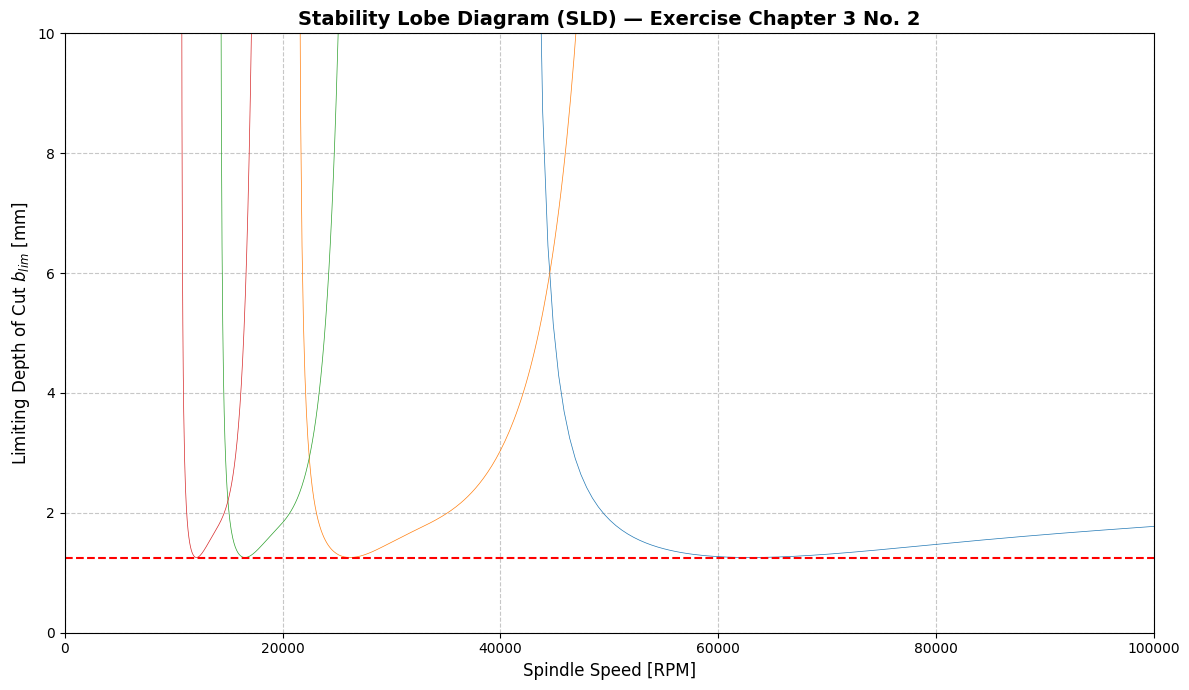

In [14]:
# ─── Filter region Re(G) < 0 (unstable) ───────────────
mask_unstable = frf_combined.real < 0
f_valid  = f_range[mask_unstable]
re_valid = frf_combined.real[mask_unstable]
im_valid = frf_combined.imag[mask_unstable]

# ─── Calculate phase ──────────────────────────────────────────
epsilon = (2 * np.pi) - (2 * np.arctan2(re_valid, im_valid)) % (2 * np.pi)

# ─── Calculate blim in mm ─────────────────────────────────
blim_valid = -1 / (2 * Ks * re_valid) * 1000   # mm
blim_crit  = blim_mm                             # from previous cell

# ─── Plot SLD ─────────────────────────────────────────────
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

plt.figure(figsize=(12, 7))

for N_lobe in range(4):
    n_speed = (60 * f_valid) / (N_lobe + (epsilon / (2 * np.pi)))
    valid_idx = (n_speed > 0) & (blim_valid > 0)
    plt.plot(
        n_speed[valid_idx],
        blim_valid[valid_idx],
        linewidth=0.5,
    )

# blim,crit line
plt.axhline(
    y=blim_crit, color='red', linestyle='--', linewidth=1.5,
    label=f'$b_{{lim,crit}}$ = {blim_crit:.2f} mm'
)

plt.title('Stability Lobe Diagram (SLD) — Exercise Chapter 3 No. 2', fontsize=14, fontweight='bold')
plt.xlabel('Spindle Speed [RPM]', fontsize=12)
plt.ylabel(r'Limiting Depth of Cut $b_{lim}$ [mm]', fontsize=12)
plt.xlim(0, 100000)
plt.ylim(0, 10)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
## e. Time Domain Simulation

### Calculation Sequence (Eq. 3.27 – 3.36):

| Step | Equation | Description |
|------|-----------|-------------|
| 3.27 | $t_n = n \cdot dt$ | Time array |
| 3.28 | $\text{steps\_rev} = 60 / (dt \cdot \Omega_{rpm})$ | Steps per revolution |
| 3.29 | $h = y_{min} - y_{n-1}$ | Chip thickness |
| 3.30 | $F = K_s \cdot b \cdot h$ | Cutting force |
| 3.31 | $F_{u1} = F\cos(\varphi-\alpha_1)$, $F_{u2} = F\cos(\varphi+\alpha_2)$ | Force resolution |
| 3.33 | $\ddot{u}_i = (F_{ui} - c_i\dot{u}_i - k_i u_i)/m_i$ | Acceleration |
| 3.34 | $\dot{u}_i^{new} = \dot{u}_i + \ddot{u}_i \cdot dt$ | Euler velocity |
| 3.35 | $u_i^{new} = u_i + \dot{u}_i \cdot dt$ | Euler position |
| 3.36 | $y_n = u_1\cos\alpha_1 + u_2\cos\alpha_2$ | Projection in normal direction |

In [15]:
# ─── Convert parameters to SI ─────────────────────────────
hm      = 0.1e-3    # m  (mean chip thickness)
alpha1  = math.radians(a1)
alpha2  = math.radians(a2)
phi_rad = math.radians(beta)

# ─── Time Domain Simulation Function ───────────────────────
def turning_time_domain(omega_rpm, b_mm, n_revolutions=50, dt_factor=50):
    """
    2-DOF turning time domain simulation.

    Parameters
    ----------
    omega_rpm    : float — spindle speed [rpm]
    b_mm         : float — chip width [mm]
    n_revolutions: int   — number of revolutions simulated
    dt_factor    : int   — period divisor (must be ≥ 10)

    Returns
    -------
    t_arr  : time array [s]
    F_arr  : cutting force array [N]
    y_out  : normal displacement array [µm]
    """
    b = b_mm * 1e-3  # m

    # --- Time step (Eq. example 3.5) ---
    fn_max = max(fn1, fn2)
    T_min  = 1.0 / fn_max
    dt     = T_min / dt_factor

    # --- Steps per revolution (Eq. 3.28) ---
    steps_rev = int(round(60.0 / (dt * omega_rpm)))

    # --- Total time steps ---
    T_total = n_revolutions * (60.0 / omega_rpm)
    n_steps = int(round(T_total / dt))

    # --- Initialization ---
    u1_pos = 0.0;  u1_vel = 0.0
    u2_pos = 0.0;  u2_vel = 0.0
    buffer = steps_rev * 0
    y_hist = np.zeros(n_steps + buffer)
    F_arr  = np.zeros(n_steps)
    t_arr  = np.zeros(n_steps)

    for n in range(n_steps):
        t_arr[n] = n * dt
        idx = n + buffer

        # Eq. 3.29 — Chip thickness
        y_n1  = y_hist[idx - steps_rev]     if (idx - steps_rev) >= 0     else 0.0
        y_n2  = y_hist[idx - 2*steps_rev]   if (idx - 2*steps_rev) >= 0   else 0.0
        ymin  = min(hm + y_n1, 2*hm + y_n2)
        y_prev = y_hist[idx - 1]             if idx > 0                    else 0.0
        h     = ymin - y_prev



        # Eq. 3.30 — Cutting force
        F_cut = Ks * b * h
        if F_cut < 0:
            F_cut = 0.0
            ymin  = y_prev
        F_arr[n] = F_cut

        # Eq. 3.31 — Force resolution in mode direction
        Fu1 = F_cut * math.cos(phi_rad - alpha1)
        Fu2 = F_cut * math.cos(phi_rad + alpha2)

        # Eq. 3.33 — Acceleration (equation of motion)
        u1_acc = (Fu1 - c1 * u1_vel - k1 * u1_pos) / m1
        u2_acc = (Fu2 - c2 * u2_vel - k2 * u2_pos) / m2
        # Eq. 3.34 — Update velocity (Euler)
        u1_vel += u1_acc * dt
        u2_vel += u2_acc * dt

        # Eq. 3.35 — Update position / displacement (Euler)
        u1_pos += u1_vel * dt
        u2_pos += u2_vel * dt

        # Eq. 3.36 — Projection in normal y direction
        yn = u1_pos * math.cos(alpha1) + u2_pos * math.cos(alpha2)
        y_hist[idx] = yn



    y_out = y_hist[buffer: buffer + n_steps] * 1e6  # µm
    return t_arr, F_arr, y_out



print("Simulation function successfully defined.")

Simulation function successfully defined.


In [7]:
cases = [
    {"omega_rpm": 44490, "b_mm": 5,  "label": "Ω = 44,490 rpm, b = 5 mm\n(Near Stability Limit)", "color_pair": ("#00d4ff", "#ff6b35")},
    {"omega_rpm": 44490, "b_mm": 6,  "label": "Ω = 44,490 rpm, b = 6 mm\n(Unstable - Chatter)", "color_pair": ("#ff4757", "#ffa502")},
    {"omega_rpm": 26140, "b_mm": 2,  "label": "Ω = 26,140 rpm, b = 2 mm\n(Unstable - Chatter)", "color_pair": ("#ff4757", "#ffa502")},
    {"omega_rpm": 26140, "b_mm": 1,  "label": "Ω = 26,140 rpm, b = 1 mm\n(Stable)", "color_pair": ("#2ed573", "#1e90ff")},
]


results = []
for case in cases:
    t, F, y = turning_time_domain(case["omega_rpm"], case["b_mm"])
    results.append({"t": t, "F": F, "y": y, **case})

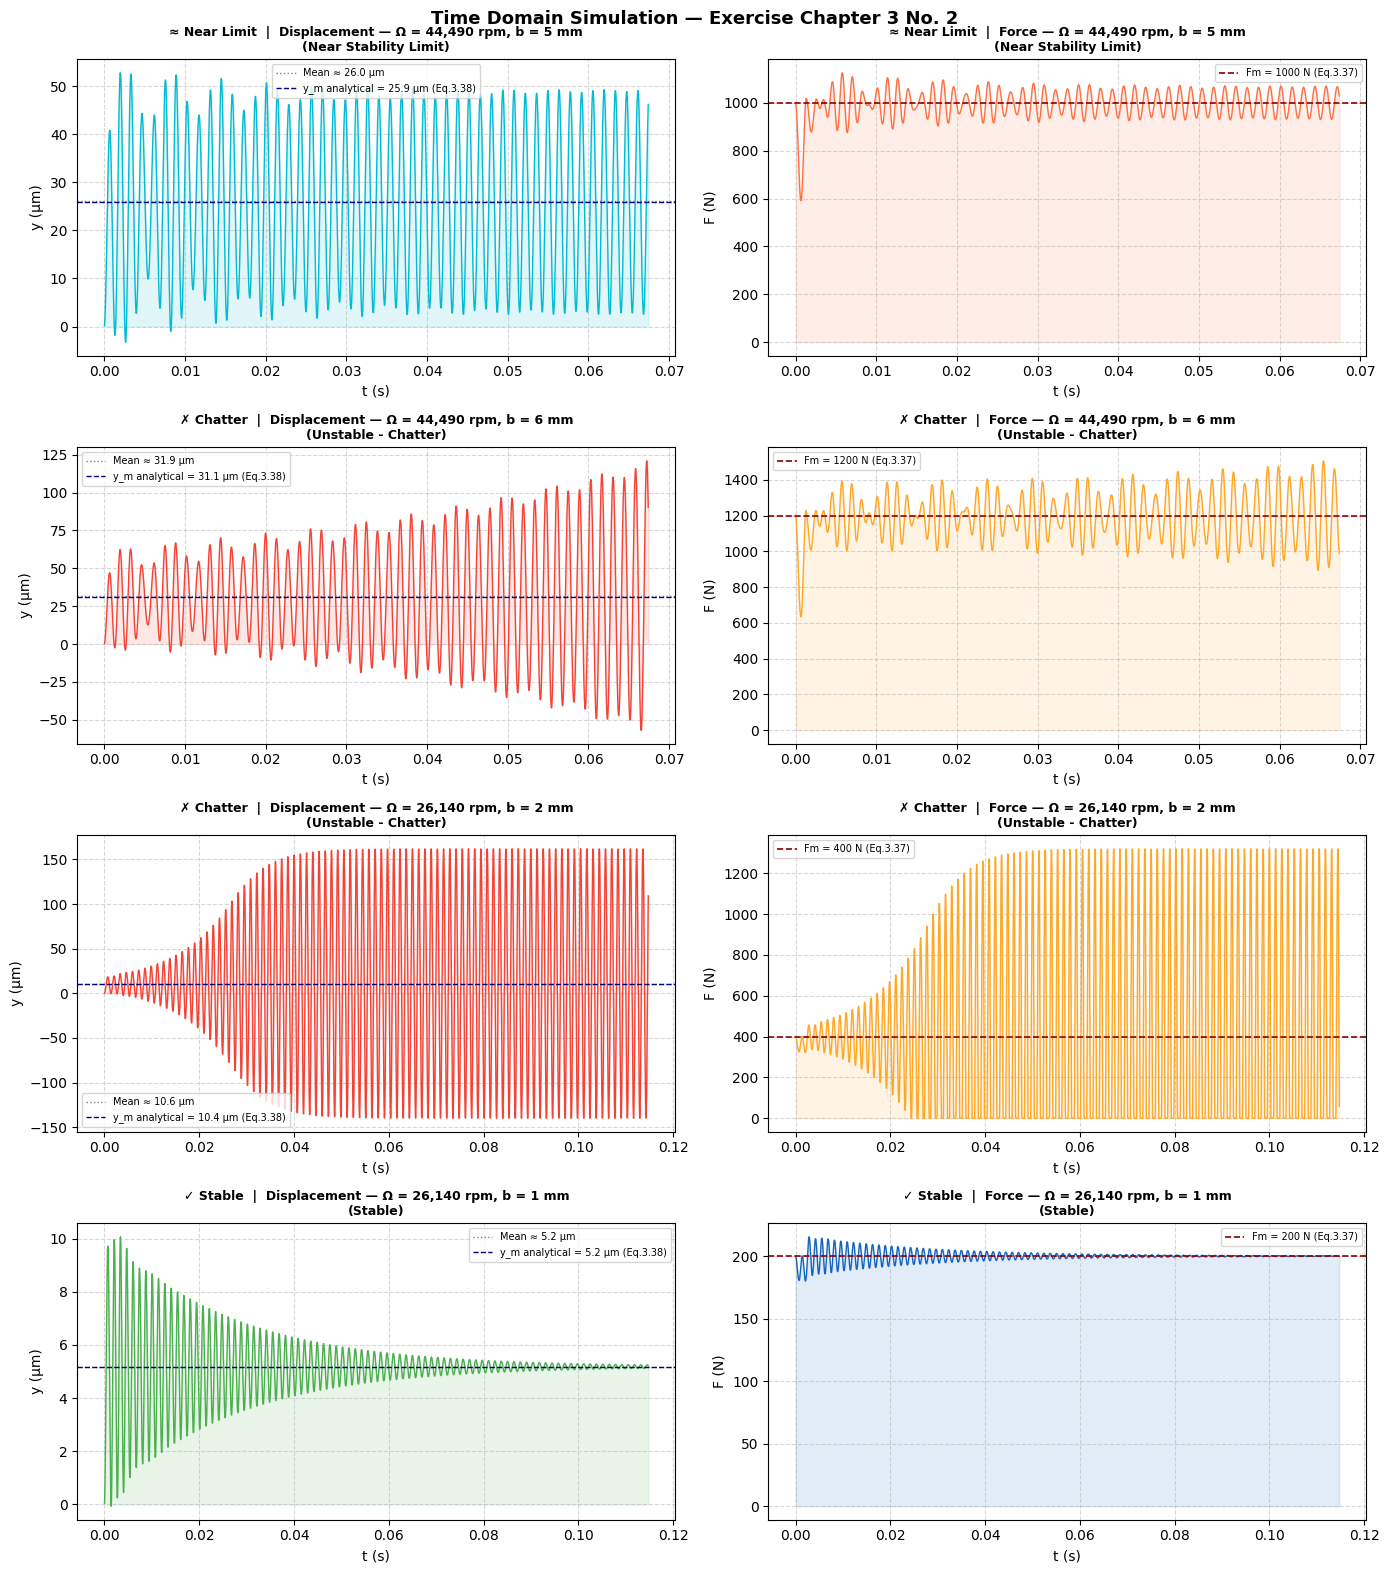

In [16]:
# ─── Plot Force and Displacement for All Scenarios ─────
colors_y = ['#00bcd4', '#f44336', '#f44336', '#4caf50']
colors_F = ['#ff7043', '#ffa726', '#ffa726', '#1565c0']
status   = ['≈ Near Limit', '✗ Chatter', '✗ Chatter', '✓ Stable']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle(
    'Time Domain Simulation — Exercise Chapter 3 No. 2',
    fontsize=13, fontweight='bold'
)

for row, (res, cy, cF, st) in enumerate(zip(results, colors_y, colors_F, status)):
    t, y, F = res['t'], res['y'], res['F']
    lbl     = res['label']
    b_SI    = res['b_mm'] * 1e-3
    Fm_ana  = Ks * b_SI * hm                              # Pers. 3.37
    ym_ana  = Fm_ana * (u1/k1 + u2/k2) * 1e6             # Pers. 3.38 [µm]

    ax_y = axes[row, 0]
    ax_F = axes[row, 1]

    # Displacement
    ax_y.plot(t, y, color=cy, linewidth=1.0)
    ax_y.fill_between(t, y, alpha=0.12, color=cy)
    ax_y.axhline(np.mean(y[-len(y)//4:]), color='gray', linestyle=':', linewidth=1,
                 label=f"Mean ≈ {np.mean(y[-len(y)//4:]):.1f} µm")
    ax_y.axhline(ym_ana, color='navy', linestyle='--', linewidth=1,
                 label=f"y_m analytical = {ym_ana:.1f} µm (Eq.3.38)")
    ax_y.set_title(f"{st}  |  Displacement — {lbl}", fontsize=9, fontweight='bold')
    ax_y.set_ylabel('y (µm)'); ax_y.set_xlabel('t (s)')
    ax_y.legend(fontsize=7); ax_y.grid(True, linestyle='--', alpha=0.5)

    # Force
    ax_F.plot(t, F, color=cF, linewidth=1.0)
    ax_F.fill_between(t, F, alpha=0.12, color=cF)
    ax_F.axhline(Fm_ana, color='darkred', linestyle='--', linewidth=1.2,
                 label=f"Fm = {Fm_ana:.0f} N (Eq.3.37)")
    ax_F.set_title(f"{st}  |  Force — {lbl}", fontsize=9, fontweight='bold')
    ax_F.set_ylabel('F (N)'); ax_F.set_xlabel('t (s)')
    ax_F.legend(fontsize=7); ax_F.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## f. Analytical Validation (Eq. 3.37 & 3.38)

$$F_m = K_s \cdot b \cdot h_m \qquad (\text{Eq. 3.37})$$

$$y_m = F_m \left(\frac{\mu_1}{k_1} + \frac{\mu_2}{k_2}\right) \qquad (\text{Eq. 3.38})$$

In [17]:
print(f"{'Condition':<35} | {'Fm Ana [N]':>10} | {'ym Ana [um]':>11} | {'F_sim [N]':>9} | {'y_sim [um]':>10}")
print("-" * 85)

for res in results:
    b_SI   = res['b_mm'] * 1e-3
    Fm_ana = Ks * b_SI * hm
    ym_ana = Fm_ana * (u1/k1 + u2/k2) * 1e6

    t, F, y = res['t'], res['F'], res['y']
    n_ss    = len(t) // 4
    F_sim   = np.mean(F[-n_ss:])
    y_sim   = np.mean(y[-n_ss:])

    cond = f"{res['omega_rpm']} rpm, b={res['b_mm']}mm"
    print(f"{cond:<35} | {Fm_ana:>10.1f} | {ym_ana:>11.2f} | {F_sim:>9.1f} | {y_sim:>10.2f}")

print("\nNote: F_sim should approach Fm_ana for stable conditions.")

Condition                           | Fm Ana [N] | ym Ana [um] | F_sim [N] | y_sim [um]
-------------------------------------------------------------------------------------
44490 rpm, b=5mm                    |     1000.0 |       25.91 |    1000.3 |      26.01
44490 rpm, b=6mm                    |     1200.0 |       31.09 |    1199.4 |      31.84
26140 rpm, b=2mm                    |      400.0 |       10.36 |     449.9 |      10.44
26140 rpm, b=1mm                    |      200.0 |        5.18 |     200.0 |       5.18

Note: F_sim should approach Fm_ana for stable conditions.
